# ODE 1 notebook

## Euler

Consider the differential equation:

$$
\frac{dx}{dt} = -x^3 t
$$

This is a nonlinear equation that can still be solved analytically. We can rewrite the 
equation as:

$$
\frac{dx}{x^3} = -t dt
$$

We integrate on both sides to get:

$$
\frac{1}{2x^2} = \frac{t^2}{2} + C
$$

or

$$
x(t) = \frac{\pm 1}{\sqrt{t^2 + C'}}
$$

The initial condition is that $x(0) = 1$, hence $C = 1$ and we have the final equation:

$$
x(t) = \frac{1}{\sqrt{t^2 + 1}}
$$

We can also use the Euler method to solve it. We build the solution one step at a time using:

$$
x(t+h) = x(t) + h f(x, t)
$$

where

$$
f(x, t) = \frac{dx}{dt} = -x^3 t
$$

We can apply Euler's method and compare the result to the analytical solution between $t=0$ and $t = 2$.

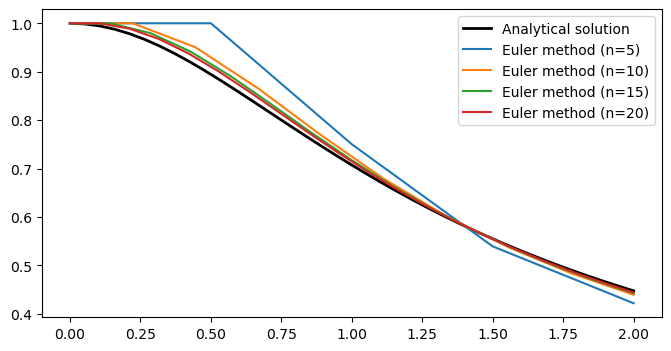

In [59]:
import numpy as np 
import matplotlib.pyplot as plt 

def dxdt(x, t):
    return -x**3*t 

def xt(t):
    return 1/np.sqrt(t**2+1)

# Number of points in the analytical solution
N_ref = 1000

# Number of points in the Euler solution
N = [5, 10, 15, 20]

# Maximum time
t_max = 2

# Starting location
x0 = 1

# Time axis for analytical solution
t_ref = np.linspace(0, t_max, num=N_ref)

def euler(f, N, x0, t_max):
    t = np.linspace(0, t_max, num=N)
    dt = t[1]-t[0]
    x = np.zeros(N)

    # Set initial position
    x[0] = x0

    # Calculate Euler
    for i in range(1,N):
        x[i] = x[i-1] + dt*f(x[i-1], t[i-1])

    return [x, t]
    
fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(t, xt(t), 'k', linewidth=2, label="Analytical solution")
for n in N:
    x, t = euler(dxdt, n, x0, t_max)
    axes.plot(t, x, label=f"Euler method (n={n})")

axes.legend(loc='upper right')
plt.show()


We see that the Euler method is producing a solution that is close to the analytical function with increasing accuracy as n increases.

### Error in Euler: single step

The error in a single step of the Euler method is $O(h^2)$. Using the same
function as above, we test that below. We focus on the first step ($t_0
\rightarrow t_0+h$ with $t_0 = 0$) in the array such that:

error = |(Euler method at $t_0+h$) - (Analytical solution at $t_0+h$)|



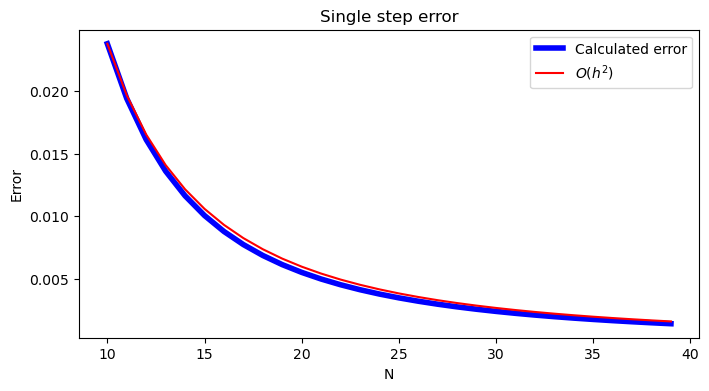

In [65]:
N_max = 40

N = np.arange(10,N_max)
error = np.zeros(N_max-10)
error_tot = np.zeros(N_max-10)

for i, n in enumerate(N):
    x, t = euler(dxdt, n, x0, t_max)
    error[i] = np.abs(x[1]-xt(t[1]))
    error_tot[i] = np.abs(x[-1]-xt(t[-1]))

fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(N, error, linewidth=4, color='b', label='Calculated error')
axes.plot(N, np.max(error)*N[0]**2/N**2, 'r', label=r'$O(h^2)$')
axes.set_xlabel("N")
axes.set_ylabel("Error")
axes.legend(loc='upper right')
axes.set_title("Single step error")

plt.show()

We see good agreement between the calculated error and the expected $1/h^2$ dependency.

### Total error in Euler

We can also look at the total error calculated in the previous cell. We calculate:

error\_tot = |(Euler at t\_max) - (Analytical solution at t\_max)|

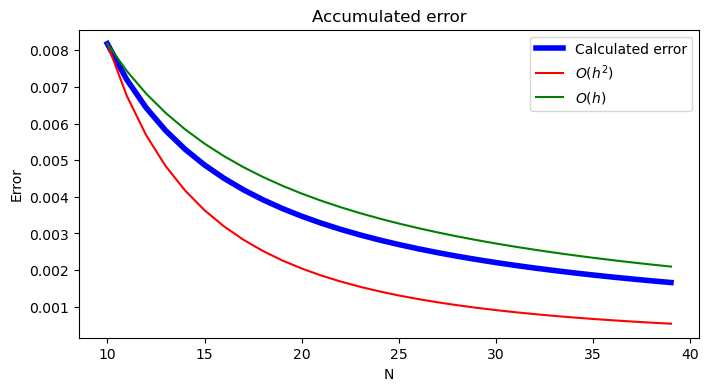

In [66]:
fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(N, error_tot, linewidth=4, color='b', label='Calculated error')
axes.plot(N, np.max(error_tot)*N[0]**2/N**2, 'r', label=r'$O(h^2)$')
axes.plot(N, np.max(error_tot)*N[0]/N, 'g', label=r'$O(h)$')
axes.set_xlabel("N")
axes.set_ylabel("Error")
axes.legend(loc='upper right')
axes.set_title("Accumulated error")

plt.show()


The total error is larger than the single step error and closer to $O(h)$ than
$O(h^2)$. Small discrepancies are likely due to the specific shape of the
function being evaluated.  

## RK2

For the second order Runge-Kutta method, use the following equations:

$$
k_1 = h f(x, t)
$$

$$
k_2 = h f(x+\frac{1}{2}k_1, t+\frac{1}{2}h)
$$

and 

$$
x(t+h) = x(t) + k_2
$$

We apply this method to the same equation as before:

$$
f(x, t) = \frac{dx}{dt} = -x^3 t
$$


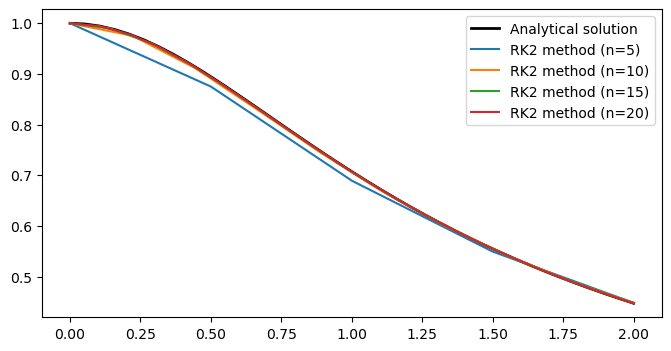

In [80]:
N = [5, 10, 15, 20]

def rk2(f, N, x0, t_max):
    t = np.linspace(0, t_max, num=N)
    dt = t[1]-t[0]
    x = np.zeros(N)

    # Set initial position
    x[0] = x0

    for i in range(1,N):
        k1 = dt*f(x[i-1], t[i-1])
        k2 = dt*f(x[i-1]+0.5*k1, t[i-1]+0.5*dt)
        x[i] = x[i-1] + k2

    return [x, t]

fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(t, xt(t), 'k', linewidth=2, label="Analytical solution")
for n in N:
    x, t = rk2(dxdt, n, x0, t_max)
    axes.plot(t, x, label=f"RK2 method (n={n})")

axes.legend(loc='upper right')
plt.show()

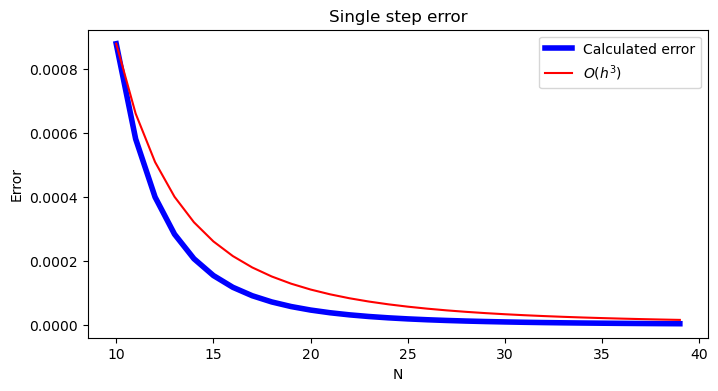

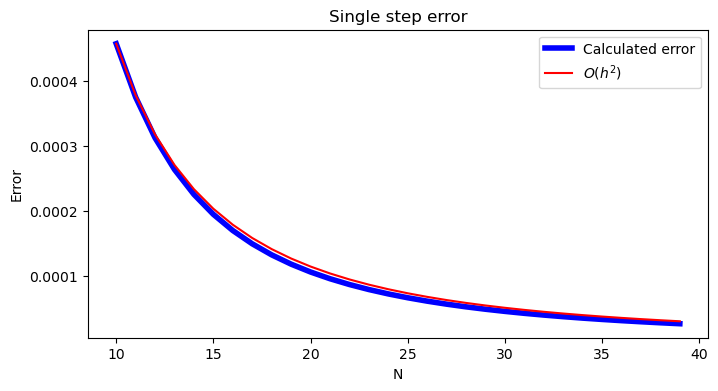

In [78]:
N_max = 40

N = np.arange(10,N_max)
error = np.zeros(N_max-10)
error_tot = np.zeros(N_max-10)

for i, n in enumerate(N):
    x, t = rk2(dxdt, n, x0, t_max)
    error[i] = np.abs(x[1]-xt(t[1]))
    error_tot[i] = np.abs(x[-1]-xt(t[-1]))

fig1, axes1 = plt.subplots(1, 1, figsize=(8,4))
axes1.plot(N, error, linewidth=4, color='b', label='Calculated error')
axes1.plot(N, np.max(error)*N[0]**3/N**3, 'r', label=r'$O(h^3)$')
axes1.set_xlabel("N")
axes1.set_ylabel("Error")
axes1.legend(loc='upper right')
axes1.set_title("Single step error")

fig2, axes2 = plt.subplots(1, 1, figsize=(8,4))
axes2.plot(N, error_tot, linewidth=4, color='b', label='Calculated error')
axes2.plot(N, np.max(error_tot)*N[0]**2/N**2, 'r', label=r'$O(h^2)$')
axes2.set_xlabel("N")
axes2.set_ylabel("Error")
axes2.legend(loc='upper right')
axes2.set_title("Single step error")


plt.show()


The errors for a single step is below $O(h^3)$. The accumulated error is below $O(h^2)$. 

We can compare the accumulated errors.

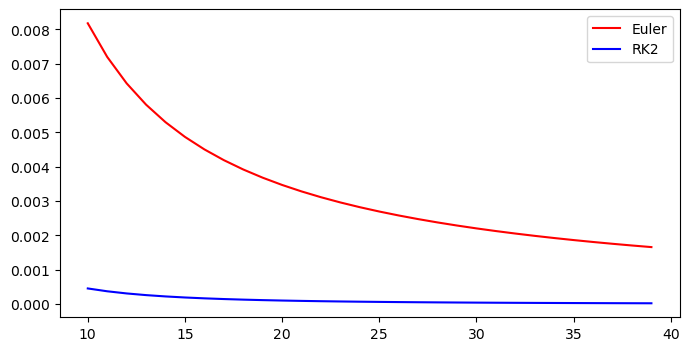

In [79]:
N_max = 40

N = np.arange(10,N_max)
error_euler = np.zeros(N_max-10)
error_rk2 = np.zeros(N_max-10)

for i, n in enumerate(N):
    x, t = euler(dxdt, n, x0, t_max)
    error_euler[i] = np.abs(x[-1]-xt(t[-1]))
    x, t = rk2(dxdt, n, x0, t_max)
    error_rk2[i] = np.abs(x[-1]-xt(t[-1]))

fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(N, error_euler, 'r', label="Euler")
axes.plot(N, error_rk2, 'b', label="RK2")
axes.legend(loc='upper right')

plt.show()


The error for N = 10 with RK2 is better than N = 40 with Euler.

## RK4

For fourth order Runge-Kutta, use the following equations:

$$
k_1 = h f(x, t)
$$

$$
k_2 = h f(x + \frac{1}{2}k_1, t + \frac{1}{2}h)
$$

$$
k_3 = h f(x + \frac{1}{2}k_2, t + \frac{1}{2}h)
$$

$$
k_4 = h f(x + k_3, t + h)
$$

and 

$$
x(t+h) = x(t) + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$$

Again, we apply this to the example above.

Example with ODE

Error:
- Single step (how it scales with h)
- Over range (how it adds up compared to analytical solution. how it scales with h.)
- How it compares with Euler and RK2



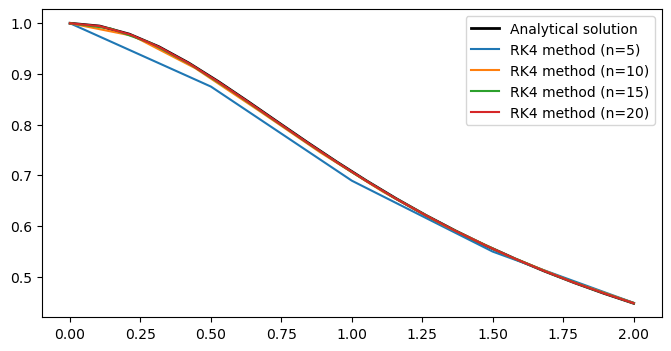

In [81]:
N = [5, 10, 15, 20]

def rk4(f, N, x0, t_max):
    t = np.linspace(0, t_max, num=N)
    dt = t[1]-t[0]
    x = np.zeros(N)

    # Set initial position
    x[0] = x0

    for i in range(1,N):
        k1 = dt*f(x[i-1], t[i-1])
        k2 = dt*f(x[i-1]+0.5*k1, t[i-1]+0.5*dt)
        k3 = dt*f(x[i-1]+0.5*k2, t[i-1]+0.5*dt)
        k4 = dt*f(x[i-1]+k3, t[i-1]+dt)
        x[i] = x[i-1] + 1/6*(k1+2*k2+2*k3+k4)

    return [x, t]

fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(t, xt(t), 'k', linewidth=2, label="Analytical solution")
for n in N:
    x, t = rk2(dxdt, n, x0, t_max)
    axes.plot(t, x, label=f"RK4 method (n={n})")

axes.legend(loc='upper right')
plt.show()


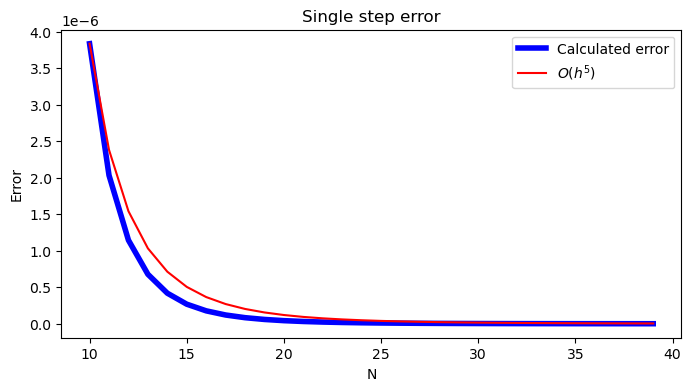

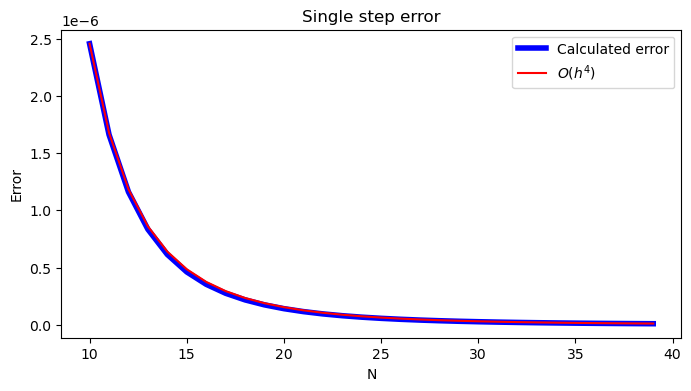

In [83]:
N_max = 40

N = np.arange(10,N_max)
error = np.zeros(N_max-10)
error_tot = np.zeros(N_max-10)

for i, n in enumerate(N):
    x, t = rk4(dxdt, n, x0, t_max)
    error[i] = np.abs(x[1]-xt(t[1]))
    error_tot[i] = np.abs(x[-1]-xt(t[-1]))

fig1, axes1 = plt.subplots(1, 1, figsize=(8,4))
axes1.plot(N, error, linewidth=4, color='b', label='Calculated error')
axes1.plot(N, np.max(error)*N[0]**5/N**5, 'r', label=r'$O(h^5)$')
axes1.set_xlabel("N")
axes1.set_ylabel("Error")
axes1.legend(loc='upper right')
axes1.set_title("Single step error")

fig2, axes2 = plt.subplots(1, 1, figsize=(8,4))
axes2.plot(N, error_tot, linewidth=4, color='b', label='Calculated error')
axes2.plot(N, np.max(error_tot)*N[0]**4/N**4, 'r', label=r'$O(h^4)$')
axes2.set_xlabel("N")
axes2.set_ylabel("Error")
axes2.legend(loc='upper right')
axes2.set_title("Single step error")


plt.show()


The error for a single step is below $O(h^5)$. The accumulated error is below $O(h^4)$.

Again, we compare the accumulated errors between the method.

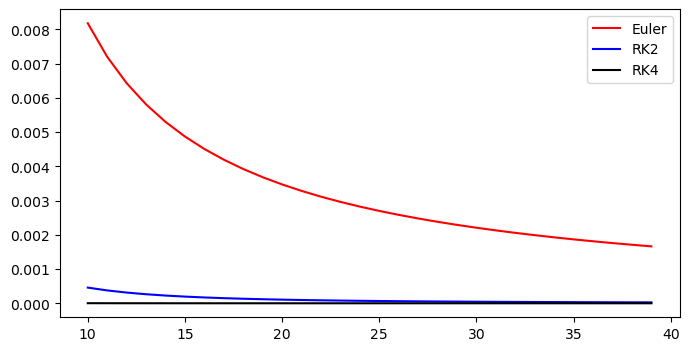

In [84]:
N_max = 40

N = np.arange(10,N_max)
error_euler = np.zeros(N_max-10)
error_rk2 = np.zeros(N_max-10)
error_rk4 = np.zeros(N_max-10)

for i, n in enumerate(N):
    x, t = euler(dxdt, n, x0, t_max)
    error_euler[i] = np.abs(x[-1]-xt(t[-1]))
    x, t = rk2(dxdt, n, x0, t_max)
    error_rk2[i] = np.abs(x[-1]-xt(t[-1]))
    x, t = rk4(dxdt, n, x0, t_max)
    error_rk4[i] = np.abs(x[-1]-xt(t[-1]))

fig, axes = plt.subplots(1, 1, figsize=(8,4))
axes.plot(N, error_euler, 'r', label="Euler")
axes.plot(N, error_rk2, 'b', label="RK2")
axes.plot(N, error_rk4, 'k', label="RK4")
axes.legend(loc='upper right')

plt.show()